# Data Exploration

This notebook explores the SCAN-B breast cancer dataset and tests the data loading pipeline.

In [1]:
import sys
sys.path.insert(0, '..')

from featsel import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Dataset

In [2]:
loader = DataLoader('../configs/scanb.yaml')

# Access data
X = loader.X
metadata = loader.metadata
y = loader.y  # Default target (PAM50)
report = loader.report

Loaded dataset: SCAN-B Breast Cancer
  Samples: 3069
  Features: 9259
  Default target: PAM50


In [3]:
print("Loading Report:")
print(report.to_string())

Loading Report:
dataset_name                     SCAN-B Breast Cancer
initial_samples                                  3069
initial_features                                 9264
samples_not_in_metadata                             0
samples_not_in_features                             0
samples_removed_all_nan                             0
features_removed_all_nan                            5
features_removed_single_value                       0
final_samples                                    3069
final_features                                   9259
target_column                                   PAM50
missing_values_remaining                            0


## 2. Explore Features

In [4]:
X.head()

,A2M,A4GNT,AAAS,AACS,AADAC,AAK1,AAMP,AARS,AASDHPPT,AASS,...,ZSCAN12,ZSCAN16,ZSCAN18,ZSCAN5A,ZW10,ZWINT,ZXDA,ZXDC,ZYX,ZZEF1
F1,-1.098234,-0.615048,-1.670827,-0.539020,0.098325,-1.989513,-0.376823,0.439949,-0.990079,-1.715000,...,-0.271914,-0.607976,-0.349919,-1.740601,0.586037,-0.067762,2.314161,0.481213,-0.277116,-1.183044
F2,0.110096,-0.615048,0.248934,0.032084,0.262344,-1.211690,-0.480422,-0.933772,-0.392950,-0.401287,...,0.316885,-0.130563,1.064711,0.578536,-0.270144,-0.381822,0.239147,-1.087827,1.399415,-1.203251
F3,-1.779393,-0.615048,-0.422635,0.392158,-0.711190,-0.210792,1.145994,1.938679,-0.093394,-2.103685,...,-2.060746,-1.840604,-1.081964,-0.807412,1.520787,1.682110,-1.593300,0.110658,0.481292,-0.641483
F4,0.268360,-0.615048,0.236302,0.563540,-0.373168,-0.839605,0.753860,1.562852,0.933071,0.329659,...,-0.812436,-0.836057,0.505783,-0.035067,-0.184722,1.094690,1.002772,0.294238,0.449014,0.854496
F5,0.616851,-0.615048,-0.988261,-0.083663,0.067739,-0.732227,-0.760831,-0.655655,-0.962107,1.256546,...,1.349677,-0.114500,0.833477,0.179142,-0.989962,-2.177457,1.244214,1.526451,0.095333,0.700526


In [5]:
X.describe()

,A2M,A4GNT,AAAS,AACS,AADAC,AAK1,AAMP,AARS,AASDHPPT,AASS,...,ZSCAN12,ZSCAN16,ZSCAN18,ZSCAN5A,ZW10,ZWINT,ZXDA,ZXDC,ZYX,ZZEF1
count,3.069000e+03,3.069000e+03,3.069000e+03,3.069000e+03,3.069000e+03,3.069000e+03,3.069000e+03,3.069000e+03,3.069000e+03,3.069000e+03,...,3.069000e+03,3.069000e+03,3.069000e+03,3.069000e+03,3.069000e+03,3.069000e+03,3.069000e+03,3.069000e+03,3.069000e+03,3.069000e+03
mean,3.704361e-17,7.177199e-16,4.827245e-16,1.296526e-16,2.685662e-16,-3.056098e-16,7.744430e-16,-1.574353e-16,-2.245769e-16,-4.167406e-17,...,3.820122e-17,-1.620658e-16,1.389135e-16,4.051645e-17,-1.886909e-16,-1.458592e-16,-5.093496e-17,2.535172e-16,4.352624e-16,3.310773e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-3.552569e+00,-6.150479e-01,-4.531602e+00,-3.236421e+00,-7.111903e-01,-3.807022e+00,-4.724992e+00,-2.582493e+00,-1.067275e+01,-3.657093e+00,...,-3.861440e+00,-5.522710e+00,-5.277052e+00,-3.979568e+00,-4.822510e+00,-4.195165e+00,-6.022635e+00,-3.662862e+00,-4.778742e+00,-7.191799e+00
25%,-6.522041e-01,-6.150479e-01,-6.130541e-01,-6.072142e-01,-7.111903e-01,-5.982589e-01,-6.208548e-01,-7.320687e-01,-6.331493e-01,-6.750988e-01,...,-6.564196e-01,-5.449116e-01,-4.950146e-01,-5.982742e-01,-6.564778e-01,-7.021657e-01,-5.627172e-01,-6.019972e-01,-6.132492e-01,-6.142150e-01
50%,-1.792847e-02,-6.150479e-01,3.004827e-02,-7.125211e-02,-3.816150e-01,1.457579e-02,8.405050e-03,-2.152229e-01,3.411901e-02,4.371566e-02,...,-1.805119e-02,5.222885e-02,1.906223e-01,-3.674278e-02,2.006808e-02,-5.733655e-03,8.587786e-02,2.017349e-02,6.706329e-02,7.837863e-02
75%,6.126706e-01,4.991537e-01,6.298689e-01,5.300347e-01,3.671197e-01,6.146637e-01,6.162476e-01,6.236176e-01,6.482466e-01,7.148382e-01,...,6.670134e-01,6.146434e-01,6.888767e-01,5.482193e-01,6.084080e-01,6.988171e-01,6.477604e-01,6.195494e-01,6.581253e-01,7.198428e-01
max,6.120072e+00,1.025882e+01,3.800926e+00,6.495278e+00,5.518580e+00,6.257380e+00,4.713971e+00,4.488572e+00,3.957668e+00,2.454732e+00,...,6.129437e+00,5.466018e+00,4.052101e+00,5.277053e+00,5.442027e+00,3.788116e+00,4.964407e+00,4.925744e+00,3.461103e+00,3.625519e+00


## 3. Explore Metadata

In [6]:
metadata.head()

,ER,PAM50,time,event,Lympho,cluster2
F1,1,Basal,2367,0,2.602223,6
F2,2,LumA,2367,0,1.104544,5
F3,2,LumB,2168,1,0.581018,5
F4,2,LumA,2416,0,2.882004,6
F5,2,Normal,2389,0,1.013356,4


In [7]:
metadata.columns.tolist()

['ER', 'PAM50', 'time', 'event', 'Lympho', 'cluster2']

## 4. Target Distribution

In [8]:
# PAM50 subtypes (main target) - already loaded as y
y.value_counts()

PAM50
LumA      1540
LumB       695
Basal      325
Her2       307
Normal     202
Name: count, dtype: int64

Target switched to: ER
Target switched to: PAM50


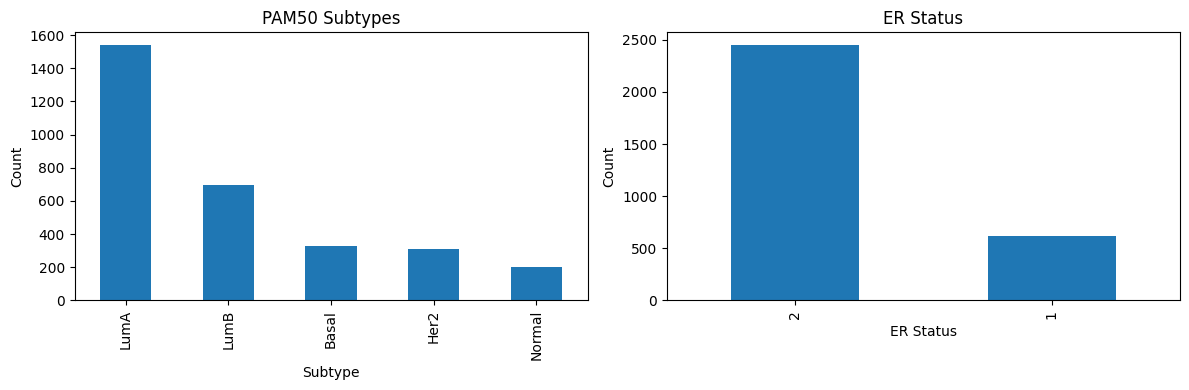

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PAM50 distribution (default target)
y.value_counts().plot(kind='bar', ax=axes[0], title='PAM50 Subtypes')
axes[0].set_xlabel('Subtype')
axes[0].set_ylabel('Count')

# ER status distribution (switch target)
y_er = loader.set_target('ER')
y_er.value_counts().plot(kind='bar', ax=axes[1], title='ER Status')
axes[1].set_xlabel('ER Status')
axes[1].set_ylabel('Count')

# Switch back to default
loader.set_target('PAM50')

plt.tight_layout()
plt.show()

## 5. Comprehensive Target Analysis

The DataLoader provides methods to analyze all target variables at once, with automatic type detection and statistics.

In [10]:
# Print formatted report of all targets
loader.print_target_report()


TARGET VARIABLE ANALYSIS

CLASSIFICATION TARGETS:
--------------------------------------------------------------------------------

ER (BINARY)
  Samples: 3069 | Missing: 0
  Classes: 2.0
  Distribution: 1: 619, 2: 2450
  Balance ratio: 0.253 (1.0 = perfectly balanced)

PAM50 (MULTICLASS)
  Samples: 3069 | Missing: 0
  Classes: 5.0
  Distribution: Basal: 325, Her2: 307, LumA: 1540, LumB: 695, Normal: 202
  Balance ratio: 0.131 (1.0 = perfectly balanced)

event (BINARY)
  Samples: 3069 | Missing: 0
  Classes: 2.0
  Distribution: 0: 2747, 1: 322
  Balance ratio: 0.117 (1.0 = perfectly balanced)

cluster2 (MULTICLASS)
  Samples: 3069 | Missing: 0
  Classes: 3.0
  Distribution: 4: 919, 5: 1285, 6: 865
  Balance ratio: 0.673 (1.0 = perfectly balanced)

REGRESSION TARGETS:
--------------------------------------------------------------------------------

time
  Samples: 3069 | Missing: 0
  Mean ± Std: 1606.103 ± 486.664
  Range: [56.000, 2474.000]
  Quartiles: Q1=1236.000, Median=1612.000, Q

In [11]:
# Get target analysis as DataFrame for programmatic access
target_report = loader.analyze_targets()
target_report

,target_name,type,n_samples,n_missing,n_classes,classes,class_counts,balance_ratio,mean,std,min,q1,median,q3,max
0,ER,binary,3069,0,2.0,"[1, 2]","1: 619, 2: 2450",0.253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PAM50,multiclass,3069,0,5.0,"['Basal', 'Her2', 'LumA', 'LumB', 'Normal']","Basal: 325, Her2: 307, LumA: 1540, LumB: 695, ...",0.131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,time,regression,3069,0,NaN,NaN,NaN,NaN,1606.103,486.664,56.000,1236.000,1612.000,2004.000,2474.000
3,event,binary,3069,0,2.0,"[0, 1]","0: 2747, 1: 322",0.117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Lympho,regression,3069,0,NaN,NaN,NaN,NaN,1.699,0.960,-0.811,1.014,1.593,2.276,5.068
5,cluster2,multiclass,3069,0,3.0,"[4, 5, 6]","4: 919, 5: 1285, 6: 865",0.673,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Key Insights

- **Balance Ratio**: For classification targets, values closer to 1.0 indicate balanced classes, while values near 0 indicate severe imbalance
- **Type Detection**: Automatically distinguishes binary, multiclass, and regression targets
- **Missing Values**: Reports help identify data quality issues

In [12]:
# Analyze class imbalance across classification targets
classification_targets = target_report[target_report['type'].isin(['binary', 'multiclass'])]
classification_targets[['target_name', 'type', 'n_classes', 'balance_ratio']]

,target_name,type,n_classes,balance_ratio
0,ER,binary,2.0,0.253
1,PAM50,multiclass,5.0,0.131
3,event,binary,2.0,0.117
5,cluster2,multiclass,3.0,0.673


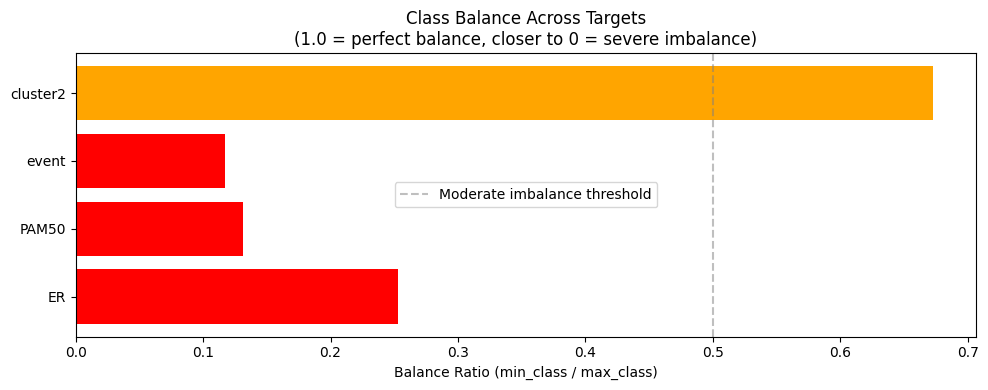

In [13]:
# Visualize class balance across targets
fig, ax = plt.subplots(figsize=(10, 4))

balance_ratios = classification_targets['balance_ratio'].astype(float)
target_names = classification_targets['target_name']

ax.barh(target_names, balance_ratios, color=['red' if r < 0.3 else 'orange' if r < 0.7 else 'green' 
                                               for r in balance_ratios])
ax.set_xlabel('Balance Ratio (min_class / max_class)')
ax.set_title('Class Balance Across Targets\n(1.0 = perfect balance, closer to 0 = severe imbalance)')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Moderate imbalance threshold')
ax.legend()

plt.tight_layout()
plt.show()